# 00 - Data Setup & EDA
**Spotify Data Mining | CISC 4631 | Group 3**

Shared notebook. Run first - loads, explores, exports 2 clean datasets to Drive.

| Output | Used by |
|--------|---------|
| `cleanedData/df_genre_balanced.csv` | Nb 01, Nb 03 |
| `cleanedData/df_popularity_stratified.csv` | Nb 02 |

**Shared constants defined here:** `AUDIO_FEATURES`, `ALL_FEATURES`, `SEED`, `YEAR_CUTOFF`, `DRIVE_DATA_PATH`

---
## Project Goals

1. Predict genre from audio features (Nb 01)
2. Predict popularity from audio features (Nb 02)
3. Content-based recommender using both classifiers (Nb 03)

### Techniques Used

**Supervised**
| Type | Used in |
|------|---------|
| Classification | Nb 01 (genre), Nb 02 (popularity) |

**Unsupervised**
| Type | Used in |
|------|---------|
| Similarity search | Nb 03 (cosine kNN recommender) |
| PCA viz | Nb 03 (audio feature space plot) |

Pipeline: supervised classifiers (Nb 01, 02) + content-based recommender (Nb 03) that loads both via pickle for re-ranking.

---
## 0. Setup

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# shared constants (copy into Nb 01/02/03)
SEED            = 42
YEAR_CUTOFF     = 2000
DRIVE_DATA_PATH = '/content/drive/MyDrive/data-mining-spotify-team3/cleanedData'
FIG_DIR         = '/content/drive/MyDrive/data-mining-spotify-team3/figures'

AUDIO_FEATURES = [
    'danceability', 'energy', 'loudness',
    'speechiness', 'acousticness', 'instrumentalness',
    'liveness', 'valence', 'tempo', 'duration_ms'
]
KEY_FEATURES = ['key', 'mode']
ALL_FEATURES = AUDIO_FEATURES + KEY_FEATURES

os.makedirs(DRIVE_DATA_PATH, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)
np.random.seed(SEED)
print('Constants loaded.')
print('ALL_FEATURES:', ALL_FEATURES)
print('Drive export path:', DRIVE_DATA_PATH)
print('Figure export path:', FIG_DIR)

---
## 1. Load Data

In [4]:
# Kaggle 550k Spotify (serkantysz) -> artists + songs CSVs
import kagglehub as kh

path = kh.dataset_download('serkantysz/550k-spotify-songs-audio-lyrics-and-genres')
print('Dataset path:', path)

# dfA = artists | dfS = songs
dfA = pd.read_csv(os.path.join(path, 'artists.csv'))
dfS = pd.read_csv(os.path.join(path, 'songs.csv'))

print(f'\nArtists: {len(dfA):,} rows | {dfA.shape[1]} columns')
print(f'Songs:   {len(dfS):,} rows | {dfS.shape[1]} columns')

Using Colab cache for faster access to the '550k-spotify-songs-audio-lyrics-and-genres' dataset.
Dataset path: /kaggle/input/550k-spotify-songs-audio-lyrics-and-genres

Artists: 71,440 rows | 6 columns
Songs:   550,622 rows | 24 columns


In [5]:
# quick peek
print('Artists Data:')
display(dfA.head())
print('\nSongs Data:')
display(dfS.head())

Artists Data:


,id,name,followers,popularity,genres,main_genre
0,6YROFUbu5zRCHi2xkir5pk,Brian Hyland,67223,47,[],Pop
1,5tFRohaO5yEsuJxmMnlCO9,Barns Courtney,602647,62,[],Electronic
2,3w1Q754jb31h5CXQCcnLNL,Capcom Sound Team,210392,58,"['japanese vgm', 'soundtrack']",Electronic
3,3oDbviiivRWhXwIE8hxkVV,The Beach Boys,5139194,76,['baroque pop'],Classical
4,60zvRmhQHRxokEB1taAVpN,Beth Malone,1569,29,['musicals'],Classical



Songs Data:


,id,name,album_name,artists,danceability,energy,key,loudness,mode,speechiness,...,tempo,duration_ms,lyrics,year,genre,popularity,total_artist_followers,avg_artist_popularity,artist_ids,niche_genres
0,0Prct5TDjAnEgIqbxcldY9,!,UNDEN!ABLE,"[""HELLYEAH""]",0.415,0.605,7,-11.157,1,0.0575,...,100.059,79500,"He said he came from Jamaica,\nhe owned a coup...",2016,Rock,0,769490,52.0,"[""4hxDvVq5t8ebPYPdBl1F9f""]","[""groove metal"", ""metal""]"
1,2ASl4wirkeYm3OWZxXKYuq,!!,Childhood Dreams,"[""Yxngxr1""]",0.788,0.648,7,-9.135,0,0.3150,...,79.998,114000,"Fuck the bitch, now she running with my kids\n...",2019,Hip-Hop,29,143628,45.0,"[""2jwRHcdgkRhelYEMqndDKe""]",[]
2,5tA3ImW310llKo8EMBj2Ga,!!Noble Stabbings!!,Situationist Comedy,"[""Dillinger Four""]",0.171,0.957,2,-5.749,1,0.1490,...,175.317,197400,You like to stand on the other side\nPoint and...,2002,Rock,0,36619,35.0,"[""4YAN46l70QV0PGXlMg0iHi""]","[""melodic hardcore"", ""pop punk"", ""punk"", ""skat..."
3,0fROT4kK5oTm8xO8PX6EJF,!I'll Be Back!,!I'll Be Back!,"[""Ril\u00e8s""]",0.823,0.612,1,-7.767,1,0.2480,...,142.959,178533,"It's been a while, shit, I missed the rehab, p...",2018,Hip-Hop,43,929303,63.0,"[""6pdcQa7by8IKuoVXvgknlI""]","[""french rap""]"
4,1xBFhv5faebv3mmwxx7DnS,!Lost!,!Lost!,"[""Ril\u00e8s""]",0.729,0.552,7,-8.562,0,0.0650,...,86.103,186197,I would like to give you all my time\nI would ...,2018,Hip-Hop,0,929303,63.0,"[""6pdcQa7by8IKuoVXvgknlI""]","[""french rap""]"


In [6]:
# merge low-count sibling genres into 7 buckets
# HipHop + R&B = high danceability / vocal-forward
# Country + Folk = high acousticness / low-energy
# Jazz + Blues = low-energy / acoustic / instrumental
GENRE_REMAP = {
    'Hip-Hop': 'Hip-Hop/R&B',
    'R&B':     'Hip-Hop/R&B',
    'Country': 'Country/Folk',
    'Folk':    'Country/Folk',
    'Jazz':    'Jazz/Blues',
    'Blues':   'Jazz/Blues',
}
dfS['genre'] = dfS['genre'].replace(GENRE_REMAP)
print('Genre counts after consolidation:')
print(dfS['genre'].value_counts())

Genre counts after consolidation:
genre
Rock            197168
Country/Folk     96919
Pop              72539
Electronic       69755
Hip-Hop/R&B      69082
Jazz/Blues       32986
Classical        12173
Name: count, dtype: int64


---
## 2. EDA - Artists (`dfA`)

### 2.1 Artist Dataset Overview

In [7]:
# dfA: shape, dtypes, missing counts
print(dfA.info())
print('\nMissing Values:')
print(dfA.isnull().sum())
print('\nArtist columns:', dfA.columns.tolist())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71440 entries, 0 to 71439
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          71440 non-null  object
 1   name        71438 non-null  object
 2   followers   71440 non-null  int64 
 3   popularity  71440 non-null  int64 
 4   genres      71440 non-null  object
 5   main_genre  71440 non-null  object
dtypes: int64(2), object(4)
memory usage: 3.3+ MB
None

Missing Values:
id            0
name          2
followers     0
popularity    0
genres        0
main_genre    0
dtype: int64

Artist columns: ['id', 'name', 'followers', 'popularity', 'genres', 'main_genre']


### 2.2 Artist Followers Distribution

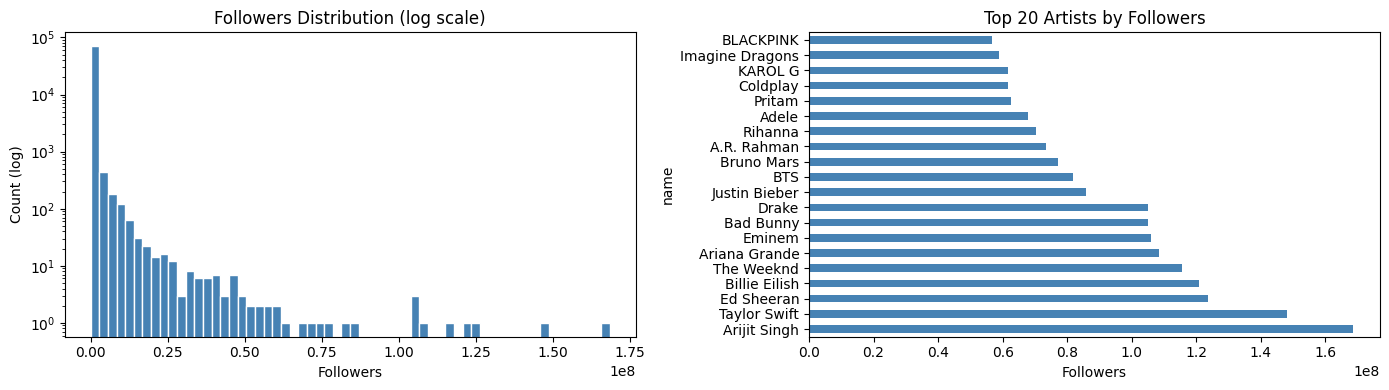

count    7.144000e+04
mean     2.330490e+05
std      2.204255e+06
min      0.000000e+00
25%      9.127500e+02
50%      7.865000e+03
75%      4.510750e+04
max      1.685087e+08
Name: followers, dtype: float64


In [8]:
# followers dist (log scale) + top 20 artists
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# raw dist, log for outliers
axes[0].hist(dfA['followers'].dropna(), bins=60, color='steelblue', edgecolor='white', log=True)
axes[0].set_title('Followers Distribution (log scale)')
axes[0].set_xlabel('Followers')
axes[0].set_ylabel('Count (log)')

# top 20 by followers
top_artists = dfA.nlargest(20, 'followers')[['name', 'followers']].set_index('name')
top_artists['followers'].plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Top 20 Artists by Followers')
axes[1].set_xlabel('Followers')

plt.tight_layout()
plt.show()

print(dfA['followers'].describe())

### 2.3 Artist Popularity by Genre

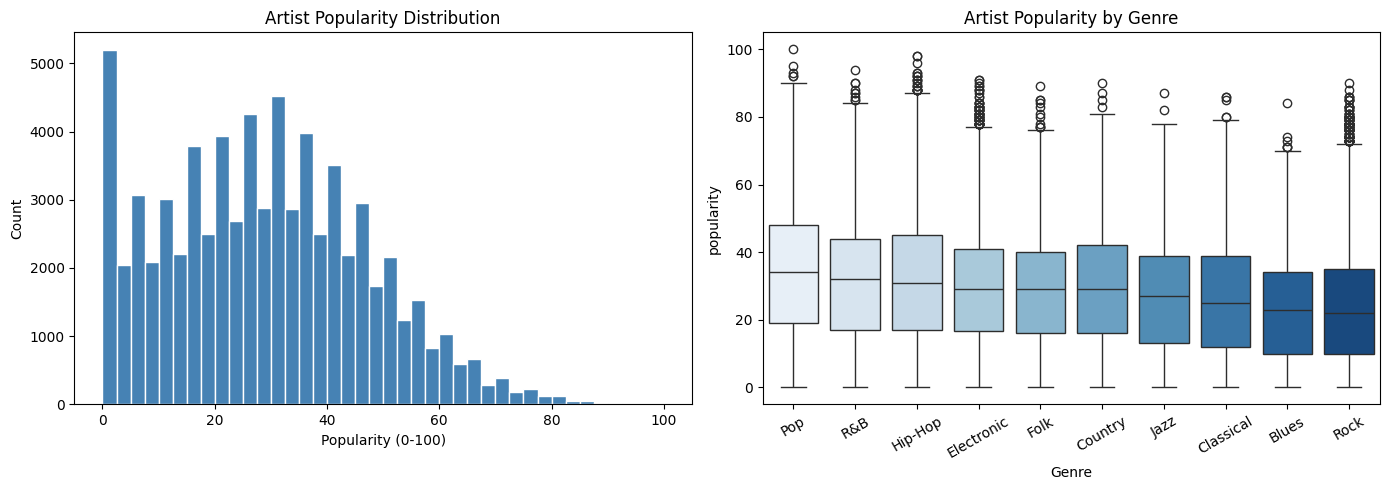

In [9]:
# artist pop dist + boxplot by main_genre
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(dfA['popularity'].dropna(), bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Artist Popularity Distribution')
axes[0].set_xlabel('Popularity (0-100)')
axes[0].set_ylabel('Count')

if 'main_genre' in dfA.columns:
    genre_order = dfA.groupby('main_genre')['popularity'].median().sort_values(ascending=False).index
    sns.boxplot(data=dfA, x='main_genre', y='popularity', order=genre_order, palette='Blues', ax=axes[1])
    axes[1].set_title('Artist Popularity by Genre')
    axes[1].set_xlabel('Genre')
    axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

### 2.4 Artist Segmentation: Followers vs. Popularity

Artist segments:
segment
Underground Gem     29024
Mainstream Giant    28520
Fading Icon          7199
Rising Star          6697
Name: count, dtype: int64


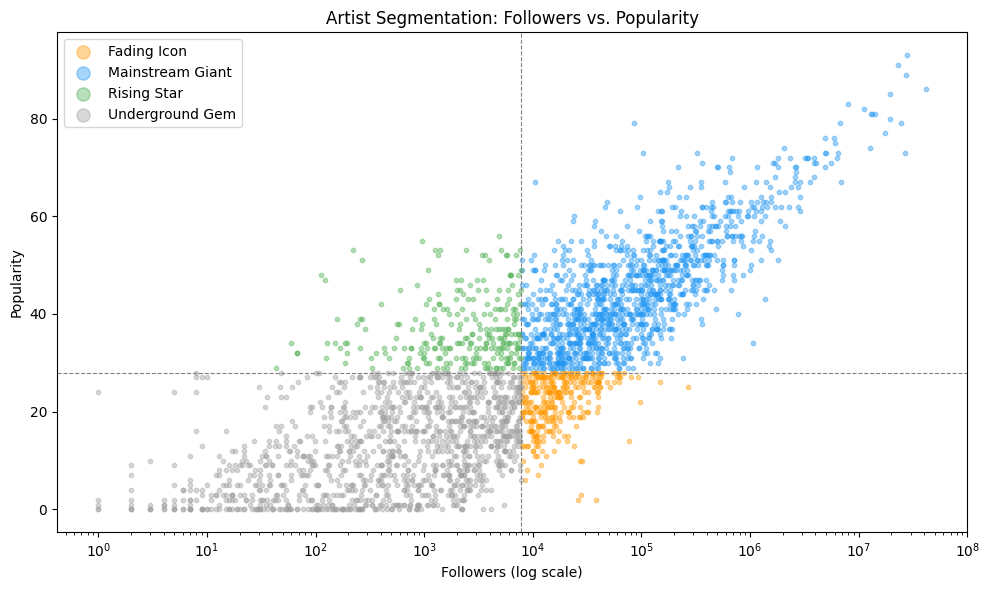

In [10]:
# segment artists into 4 quadrants on followers x popularity (median split)
dfA_clean = dfA.dropna(subset=['followers', 'popularity']).copy()

med_followers  = dfA_clean['followers'].median()
med_popularity = dfA_clean['popularity'].median()

def segment_artist(row):
    hi_f = row['followers']  > med_followers
    hi_p = row['popularity'] > med_popularity
    if hi_f and hi_p:   return 'Mainstream Giant'
    if hi_f and not hi_p: return 'Fading Icon'
    if not hi_f and hi_p: return 'Rising Star'
    return 'Underground Gem'

dfA_clean['segment'] = dfA_clean.apply(segment_artist, axis=1)
print('Artist segments:')
print(dfA_clean['segment'].value_counts())

# scatter sample for readability
sample = dfA_clean.sample(min(3000, len(dfA_clean)), random_state=SEED)
colors = {'Mainstream Giant': '#2196F3', 'Rising Star': '#4CAF50',
          'Underground Gem':  '#9E9E9E', 'Fading Icon': '#FF9800'}

plt.figure(figsize=(10, 6))
for seg, grp in sample.groupby('segment'):
    plt.scatter(grp['followers'], grp['popularity'],
                label=seg, alpha=0.4, s=10, color=colors[seg])

plt.axvline(med_followers,  color='gray', linestyle='--', linewidth=0.8)
plt.axhline(med_popularity, color='gray', linestyle='--', linewidth=0.8)
plt.xscale('log')
plt.xlabel('Followers (log scale)')
plt.ylabel('Popularity')
plt.title('Artist Segmentation: Followers vs. Popularity')
plt.legend(markerscale=3)
plt.tight_layout()
plt.show()

---
## 3. EDA - Songs (`dfS`)

### 3.1 Basic Info

In [11]:
# dfS: shape + missing cols (non-zero only)
print(dfS.info())
print('\nMissing Values:')
missing = dfS.isnull().sum()
print(missing[missing > 0])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550622 entries, 0 to 550621
Data columns (total 24 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      550622 non-null  object 
 1   name                    550619 non-null  object 
 2   album_name              550602 non-null  object 
 3   artists                 550622 non-null  object 
 4   danceability            550622 non-null  float64
 5   energy                  550622 non-null  float64
 6   key                     550622 non-null  int64  
 7   loudness                550622 non-null  float64
 8   mode                    550622 non-null  int64  
 9   speechiness             550622 non-null  float64
 10  acousticness            550622 non-null  float64
 11  instrumentalness        550622 non-null  float64
 12  liveness                550622 non-null  float64
 13  valence                 550622 non-null  float64
 14  tempo               

**Obs**
- 550k songs, 24 cols. tiny missing: name (3), album_name (20). no missing audio features.
- 10 continuous audio feats + key/mode/year/duration_ms/popularity as ints.
- lyrics/artists/artist_ids/niche_genres = string-encoded lists (need parsing).

### 3.2 Popularity Distribution

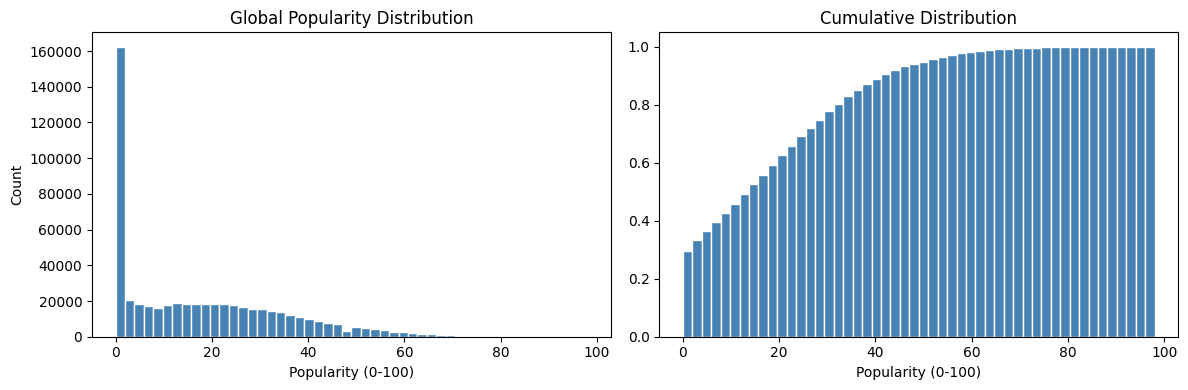

count    550622.000000
mean         17.575954
std          17.457960
min           0.000000
25%           0.000000
50%          14.000000
75%          30.000000
max          98.000000
Name: popularity, dtype: float64

Songs with 0 popularity: 148,778 (27.0%)


In [12]:
# song pop dist: hist + CDF
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(dfS['popularity'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Global Popularity Distribution')
axes[0].set_xlabel('Popularity (0-100)')
axes[0].set_ylabel('Count')

axes[1].hist(dfS['popularity'], bins=50, color='steelblue', edgecolor='white', cumulative=True, density=True)
axes[1].set_title('Cumulative Distribution')
axes[1].set_xlabel('Popularity (0-100)')

plt.tight_layout()
plt.show()

print(dfS['popularity'].describe())
print(f'\nSongs with 0 popularity: {(dfS["popularity"] == 0).sum():,} ({(dfS["popularity"] == 0).mean() * 100:.1f}%)')

**Obs**
- right-skewed, huge spike at 0. most songs barely streamed.
- mean=17.6, median=14, p75=30. ~40% have pop<=5.
- random sample = mostly Low class -> need stratified sampling.

### 3.3 Year Distribution

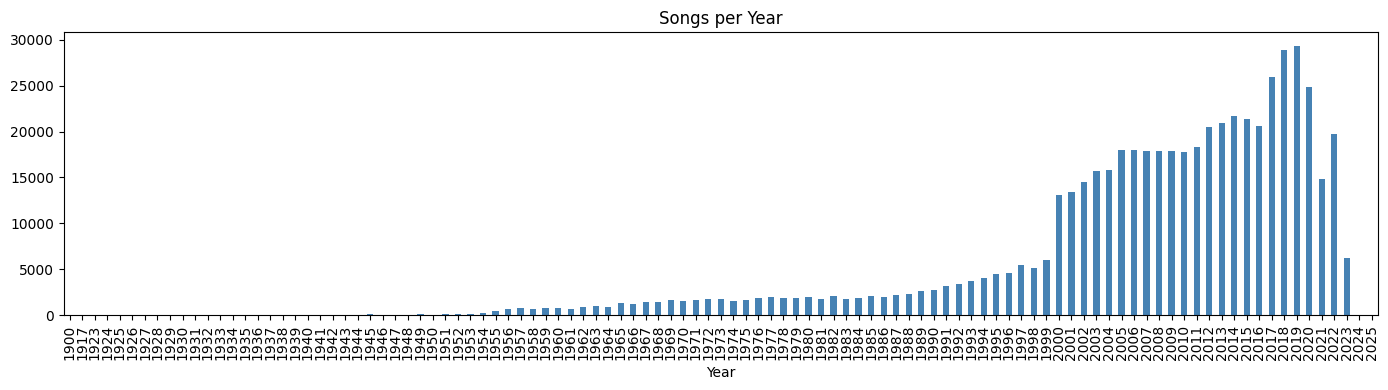

Songs from 2000+: 453,033


In [13]:
# songs per year (bar)
dfS['year'].value_counts().sort_index().plot(kind='bar', figsize=(14, 4), color='steelblue')
plt.title('Songs per Year')
plt.xlabel('Year')
plt.tight_layout()
plt.show()
print(f'Songs from {YEAR_CUTOFF}+: {(dfS["year"] >= YEAR_CUTOFF).sum():,}')

**Obs**
- exponential growth from ~2010, peaks 2020. pre-2000 sparse.
- Spotify pop = recent-streaming metric -> old catalog disadvantaged.
- **Decision:** filter year >= 2000. drops pre-digital bias, keeps 2000s.

### 3.4 Genre Distribution

In [ ]:
# genre dist (pre-filter, desc). lock order for §4.2/4.3 alignment
print('Number of unique genres:', dfS['genre'].nunique())
print('\nGenres:')
top_genres = dfS['genre'].value_counts()
print(top_genres)

GENRE_ORDER = top_genres.index.tolist()

fig, ax = plt.subplots(figsize=(10, 5))
top_genres.plot(kind='barh', color='steelblue', ax=ax)
ax.set_title('Genre Distribution (pre-filter)')
for i, v in enumerate(top_genres.values):
    ax.text(v, i, f'  {v:,}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'nb00_genre_raw.png'), dpi=150, bbox_inches='tight')
plt.show()

**Obs**
- 7 genres after merging: HipHop+R&B, Country+Folk, Jazz+Blues.
- Rock dominates (~197k, ~36%). Classical smallest (~12k pre-filter, 6,895 post-filter).
- **Decision:** keep all 7, undersample to min class (6,895) -> balanced 48,265-song dataset.

### 3.5 Popularity Within Each Genre

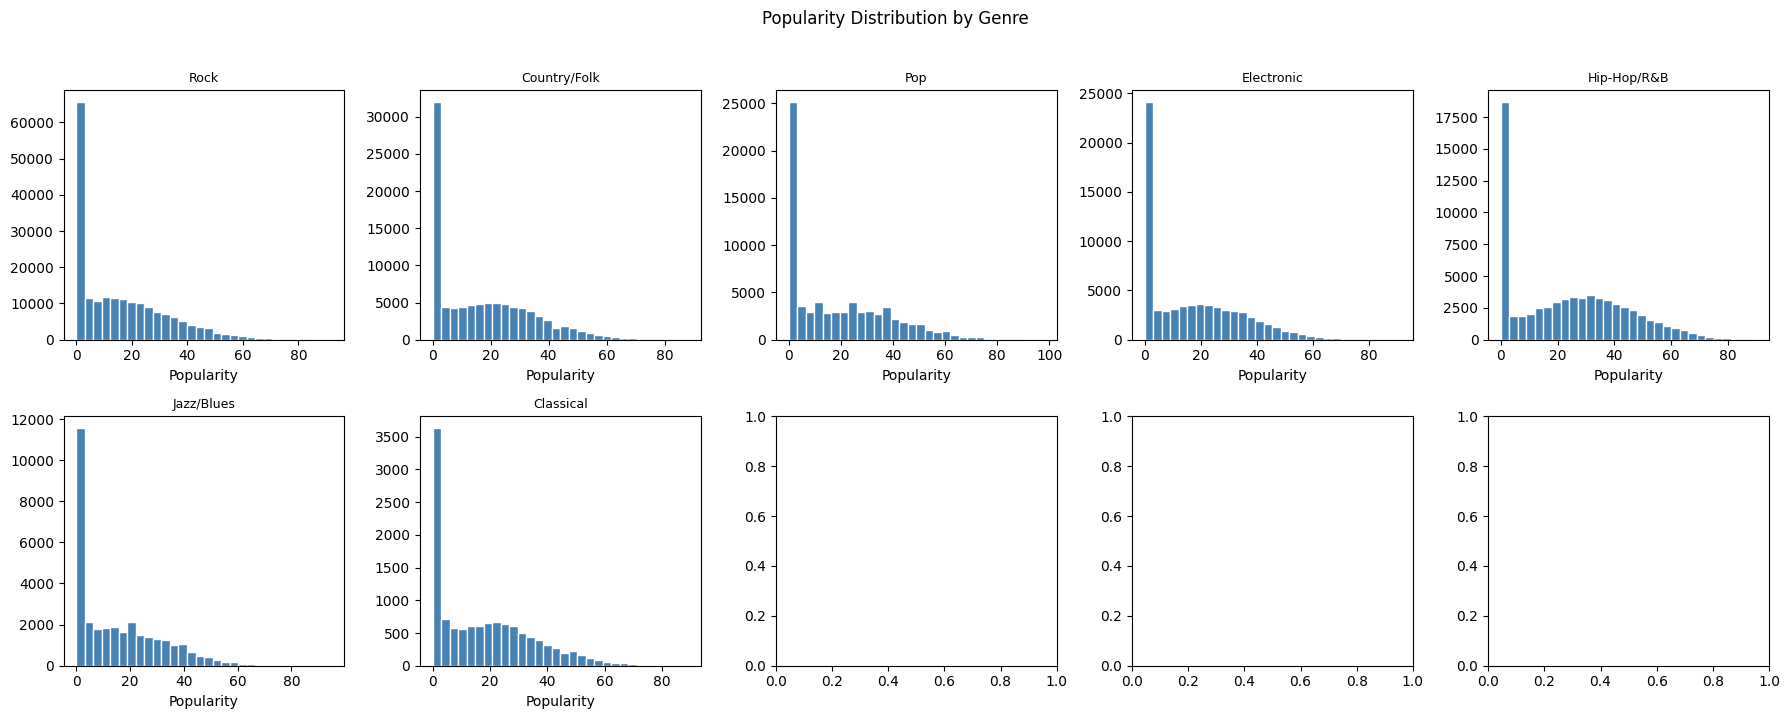

In [15]:
# per-genre popularity hist (2x5 grid)
all_genres = dfS['genre'].value_counts().index
fig, axes = plt.subplots(2, 5, figsize=(18, 7), sharey=False)

for ax, genre in zip(axes.flatten(), all_genres):
    subset = dfS[dfS['genre'] == genre]['popularity']
    ax.hist(subset, bins=30, color='steelblue', edgecolor='white')
    ax.set_title(genre[:20], fontsize=9)
    ax.set_xlabel('Popularity')

plt.suptitle('Popularity Distribution by Genre', y=1.02)
plt.tight_layout()
plt.show()

**Obs**
- all genres right-skewed, shapes differ: Pop/HipHop wider; Rock/Folk/Classical pile near 0.
- "popular" = genre-dependent (Pop@30 = avg, Classical@30 = standout).
- **Implication:** add genre-relative pop label as 2nd target in Nb 02.

### 3.6 Audio Feature Correlation with Popularity

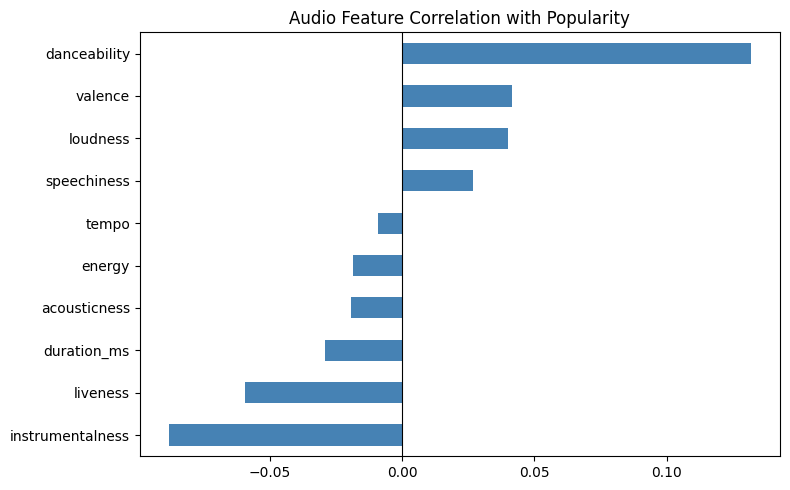

instrumentalness   -0.088211
liveness           -0.059443
duration_ms        -0.029100
acousticness       -0.019313
energy             -0.018729
tempo              -0.009093
speechiness         0.026919
loudness            0.040155
valence             0.041702
danceability        0.131839
Name: popularity, dtype: float64


In [16]:
# Pearson corr: each audio feat vs popularity
corr = dfS[AUDIO_FEATURES + ['popularity']].corr()['popularity'].drop('popularity').sort_values()
corr.plot(kind='barh', figsize=(8, 5), color='steelblue')
plt.title('Audio Feature Correlation with Popularity')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()
print(corr)

**Obs**
- all corrs weak (|r| < 0.15). no single feat = strong linear predictor.
- danceability strongest + (~0.13). instrumentalness most - (~-0.06).
- **Implication:** genre/pop prediction needs feature *interactions* -> prefer tree models over Naive Bayes.

### 3.7 Multicollinearity Check

In [ ]:
# corr matrix across audio feats + print high-corr pairs (|r|>0.5)
corr_matrix = dfS[AUDIO_FEATURES].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation Matrix of Audio Features')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'nb00_multicollinearity.png'), dpi=150, bbox_inches='tight')
plt.show()

print('High-correlation pairs (|r| > 0.5):')
for i in range(len(AUDIO_FEATURES)):
    for j in range(i + 1, len(AUDIO_FEATURES)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.5:
            print(f'  {AUDIO_FEATURES[i]} vs {AUDIO_FEATURES[j]}: {r:.3f}')

### 3.8 Audio Features by Popularity Tier

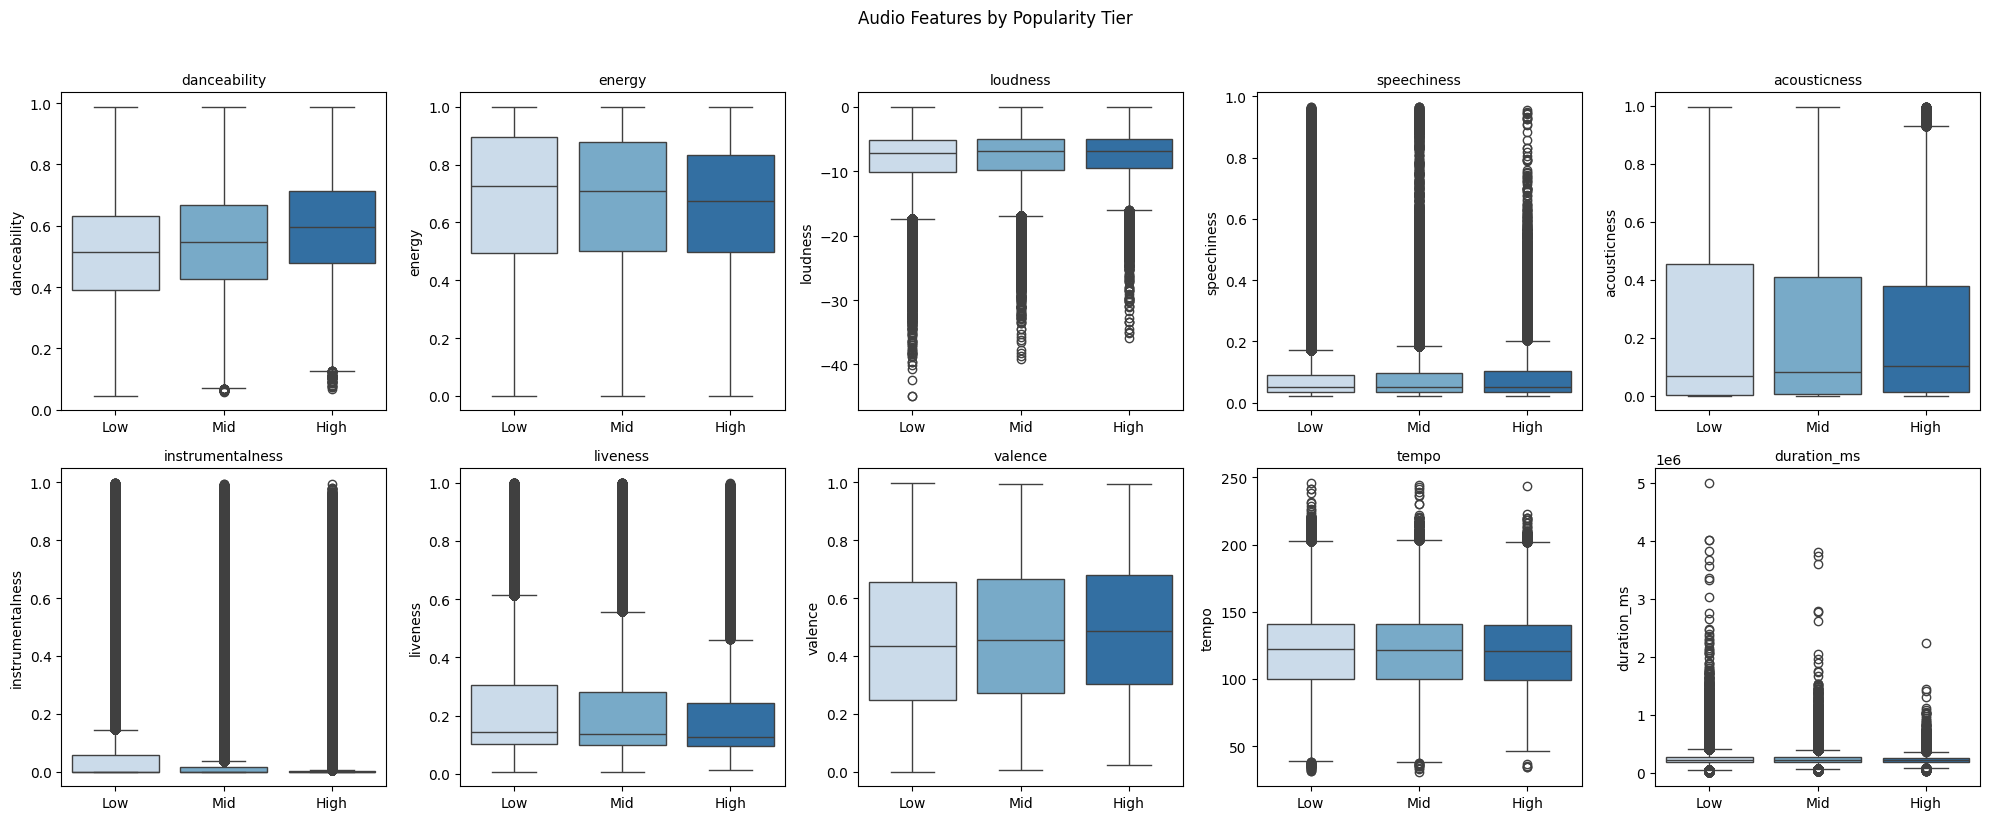

In [18]:
# boxplot: each audio feat across Low/Mid/High pop tiers
temp = dfS.copy()
temp['pop_tier'] = pd.cut(
    temp['popularity'], bins=[0, 20, 45, 100],
    labels=['Low', 'Mid', 'High'], include_lowest=True
)

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for ax, feat in zip(axes.flatten(), AUDIO_FEATURES):
    sns.boxplot(data=temp, x='pop_tier', y=feat, ax=ax, palette='Blues', order=['Low', 'Mid', 'High'])
    ax.set_title(feat, fontsize=10)
    ax.set_xlabel('')

plt.suptitle('Audio Features by Popularity Tier', y=1.02)
plt.tight_layout()
plt.show()

### 3.9 Genre-Stratified Feature-Popularity Correlations

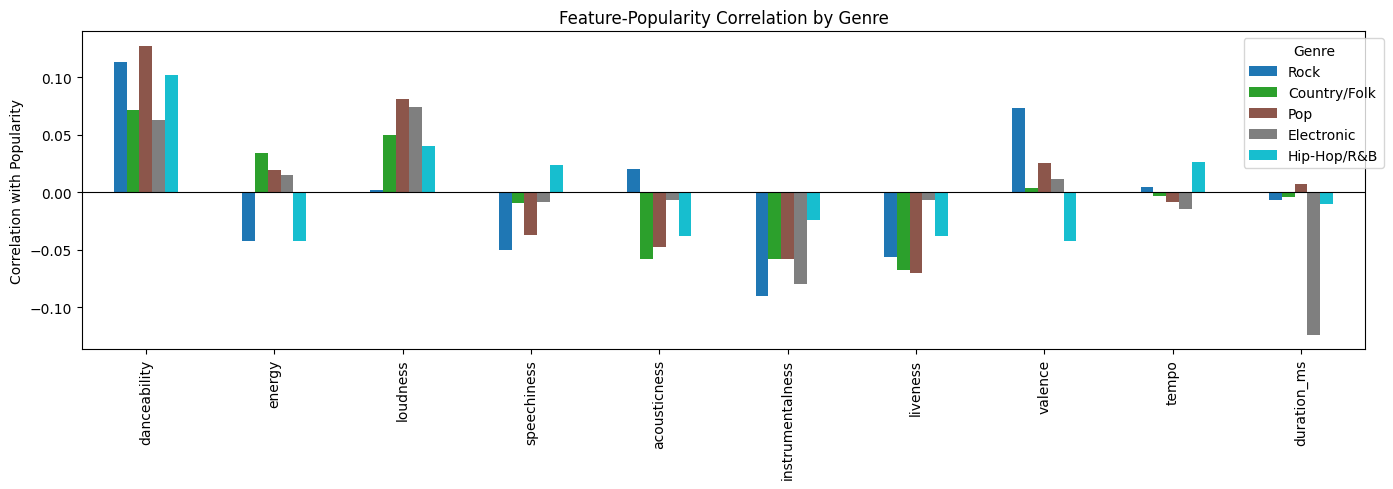

In [19]:
# feat-pop corr stratified by top 5 genres
top_5_genres = dfS['genre'].value_counts().head(5).index

genre_corrs = {}
for genre in top_5_genres:
    subset = dfS[dfS['genre'] == genre]
    genre_corrs[genre] = subset[AUDIO_FEATURES + ['popularity']].corr()['popularity'].drop('popularity')

genre_corr_df = pd.DataFrame(genre_corrs)
genre_corr_df.plot(kind='bar', figsize=(14, 5), colormap='tab10')
plt.title('Feature-Popularity Correlation by Genre')
plt.ylabel('Correlation with Popularity')
plt.axhline(0, color='black', linewidth=0.8)
plt.legend(title='Genre', bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

**Obs**
- feat-pop corrs vary a lot across genres -> genre context matters.
- danceability -> pop in HipHop/Pop but weak in Country/Electronic.
- same features, different predictive weight per genre.

### 3.10 Audio Features by Genre

In [ ]:
# boxplot: each audio feat across 7 genres (fliers hidden for clarity)
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
genre_order = sorted(dfS['genre'].unique())

for ax, feat in zip(axes.flatten(), AUDIO_FEATURES):
    sns.boxplot(data=dfS, x='genre', y=feat, order=genre_order,
                palette='Blues', ax=ax, showfliers=False)
    ax.set_title(feat, fontsize=10)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30, labelsize=8)

plt.suptitle('Audio Features by Genre', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'nb00_boxplots_by_genre.png'), dpi=150, bbox_inches='tight')
plt.show()

### 3.11 Feature Skew

In [ ]:
# skewness table + horizontal bar chart (flags features that may need log transform)
from scipy.stats import skew as skewness

skew_df = pd.DataFrame({
    'Feature': AUDIO_FEATURES,
    'Skew': [skewness(dfS[f].dropna()) for f in AUDIO_FEATURES]
}).sort_values('Skew', key=abs, ascending=True).reset_index(drop=True)

print('Feature skewness (|skew| > 1 = consider transform):')
print(skew_df.sort_values('Skew', key=abs, ascending=False).to_string(index=False))

# visualize: horizontal bar chart, color-code features over |skew| > 1
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#d62728' if abs(s) > 1 else '#2196F3' for s in skew_df['Skew']]
ax.barh(skew_df['Feature'], skew_df['Skew'], color=colors, edgecolor='white')
ax.axvline(1,  color='gray', linestyle='--', linewidth=1, label='|skew| = 1 (transform threshold)')
ax.axvline(-1, color='gray', linestyle='--', linewidth=1)
ax.axvline(0,  color='black', linewidth=0.8)
ax.set_xlabel('Skewness')
ax.set_title('Audio Feature Skew  (red = |skew| > 1, consider log transform)')
for i, v in enumerate(skew_df['Skew']):
    ax.text(v + (0.05 if v >= 0 else -0.05), i, f'{v:.2f}',
            va='center', ha='left' if v >= 0 else 'right', fontsize=8)
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'nb00_skew_chart.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Post-Filter EDA

In [22]:
# post-filter df: year>=2000, pop>0, non-null audio. reused by Section 5
df_recent = dfS[
    (dfS['year'] >= YEAR_CUTOFF) & (dfS['popularity'] > 0)
].dropna(subset=ALL_FEATURES).copy()
print(f'After year >= {YEAR_CUTOFF} + popularity > 0 filter: {len(df_recent):,} songs')
print(df_recent['genre'].value_counts())

After year >= 2000 + popularity > 0 filter: 322,800 songs
genre
Rock            117897
Country/Folk     53147
Electronic       47094
Hip-Hop/R&B      43579
Pop              40388
Jazz/Blues       13800
Classical         6895
Name: count, dtype: int64


### 4.1 Year Distribution

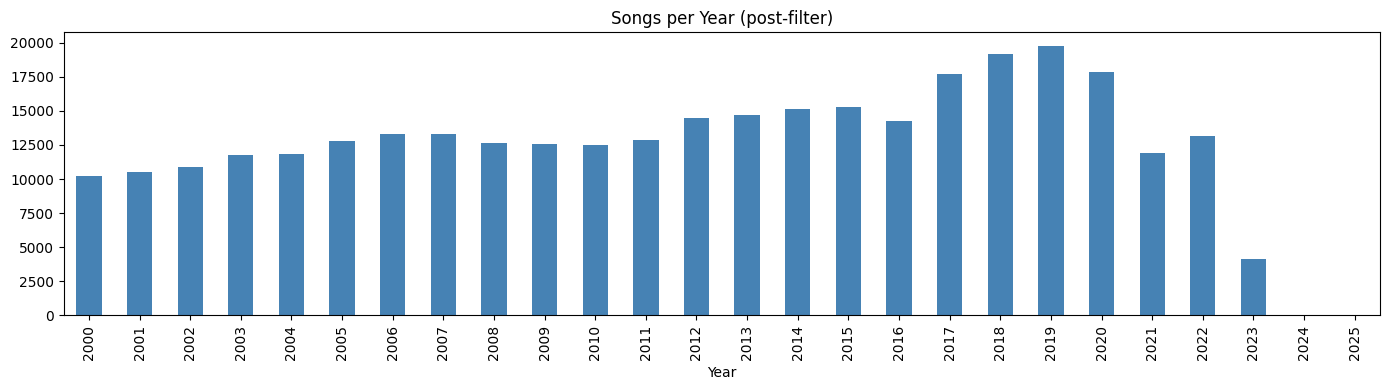

In [23]:
# post-filter year dist
df_recent['year'].value_counts().sort_index().plot(kind='bar', figsize=(14, 4), color='steelblue')
plt.title('Songs per Year (post-filter)')
plt.xlabel('Year')
plt.tight_layout()
plt.show()

### 4.2 Genre Distribution

In [ ]:
# reuse GENRE_ORDER from §3.4 for side-by-side compare
top_genres = df_recent['genre'].value_counts().reindex(GENRE_ORDER)
print(top_genres)

fig, ax = plt.subplots(figsize=(10, 5))
top_genres.plot(kind='barh', color='steelblue', ax=ax)
ax.set_title('Genre Distribution (post-filter)')
for i, v in enumerate(top_genres.values):
    ax.text(v, i, f'  {v:,}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'nb00_genre_balanced.png'), dpi=150, bbox_inches='tight')
plt.show()

### 4.3 Popularity Within Each Genre

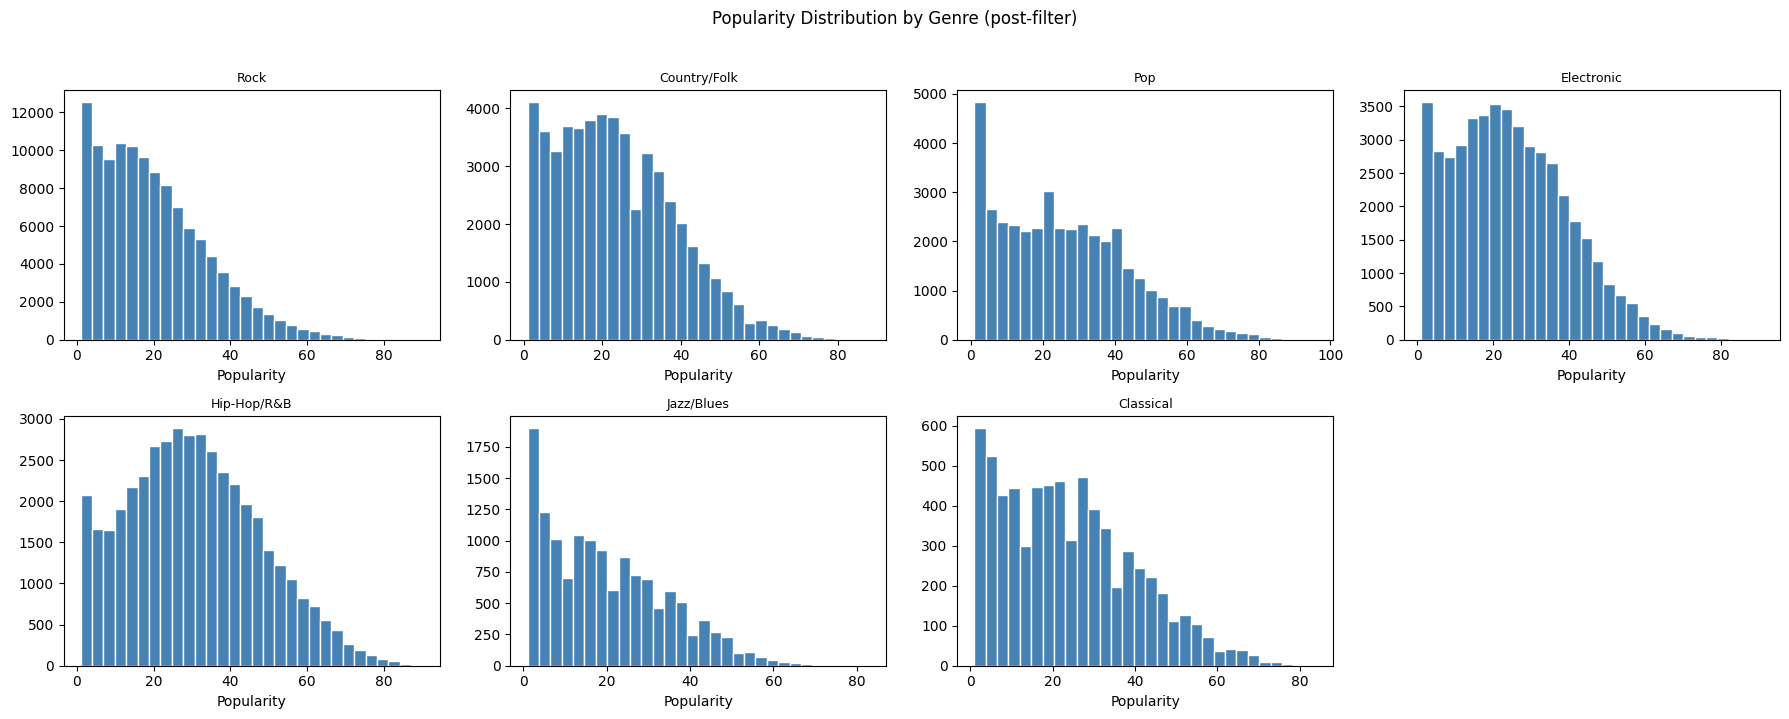

In [25]:
# post-filter per-genre popularity hist (2x4, 1 panel empty)
fig, axes = plt.subplots(2, 4, figsize=(18, 7), sharey=False)

for ax, genre in zip(axes.flatten(), GENRE_ORDER):
    subset = df_recent[df_recent['genre'] == genre]['popularity']
    ax.hist(subset, bins=30, color='steelblue', edgecolor='white')
    ax.set_title(genre[:20], fontsize=9)
    ax.set_xlabel('Popularity')

# hide empty panels (7 genres on 2x4 grid leaves 1 empty)
for i in range(len(GENRE_ORDER), len(axes.flatten())):
    axes.flatten()[i].set_visible(False)

plt.suptitle('Popularity Distribution by Genre (post-filter)', y=1.02)
plt.tight_layout()
plt.show()

### 4.4 Audio Feature Correlation with Popularity

In [ ]:
# post-filter feat-pop corr
corr = df_recent[AUDIO_FEATURES + ['popularity']].corr()['popularity'].drop('popularity').sort_values()
corr.plot(kind='barh', figsize=(8, 5), color='steelblue')
plt.title('Audio Feature Correlation with Popularity (post-filter)')
plt.axvline(0, color='black', linewidth=0.8)
# show |r|=0.15 reference lines - visual cue that all correlations are weak
plt.axvline(0.15,  color='gray', linestyle='--', linewidth=0.8)
plt.axvline(-0.15, color='gray', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'nb00_audio_pop_correlation.png'), dpi=150, bbox_inches='tight')
plt.show()
print(corr)

### 4.5 Audio Features by Popularity Tier

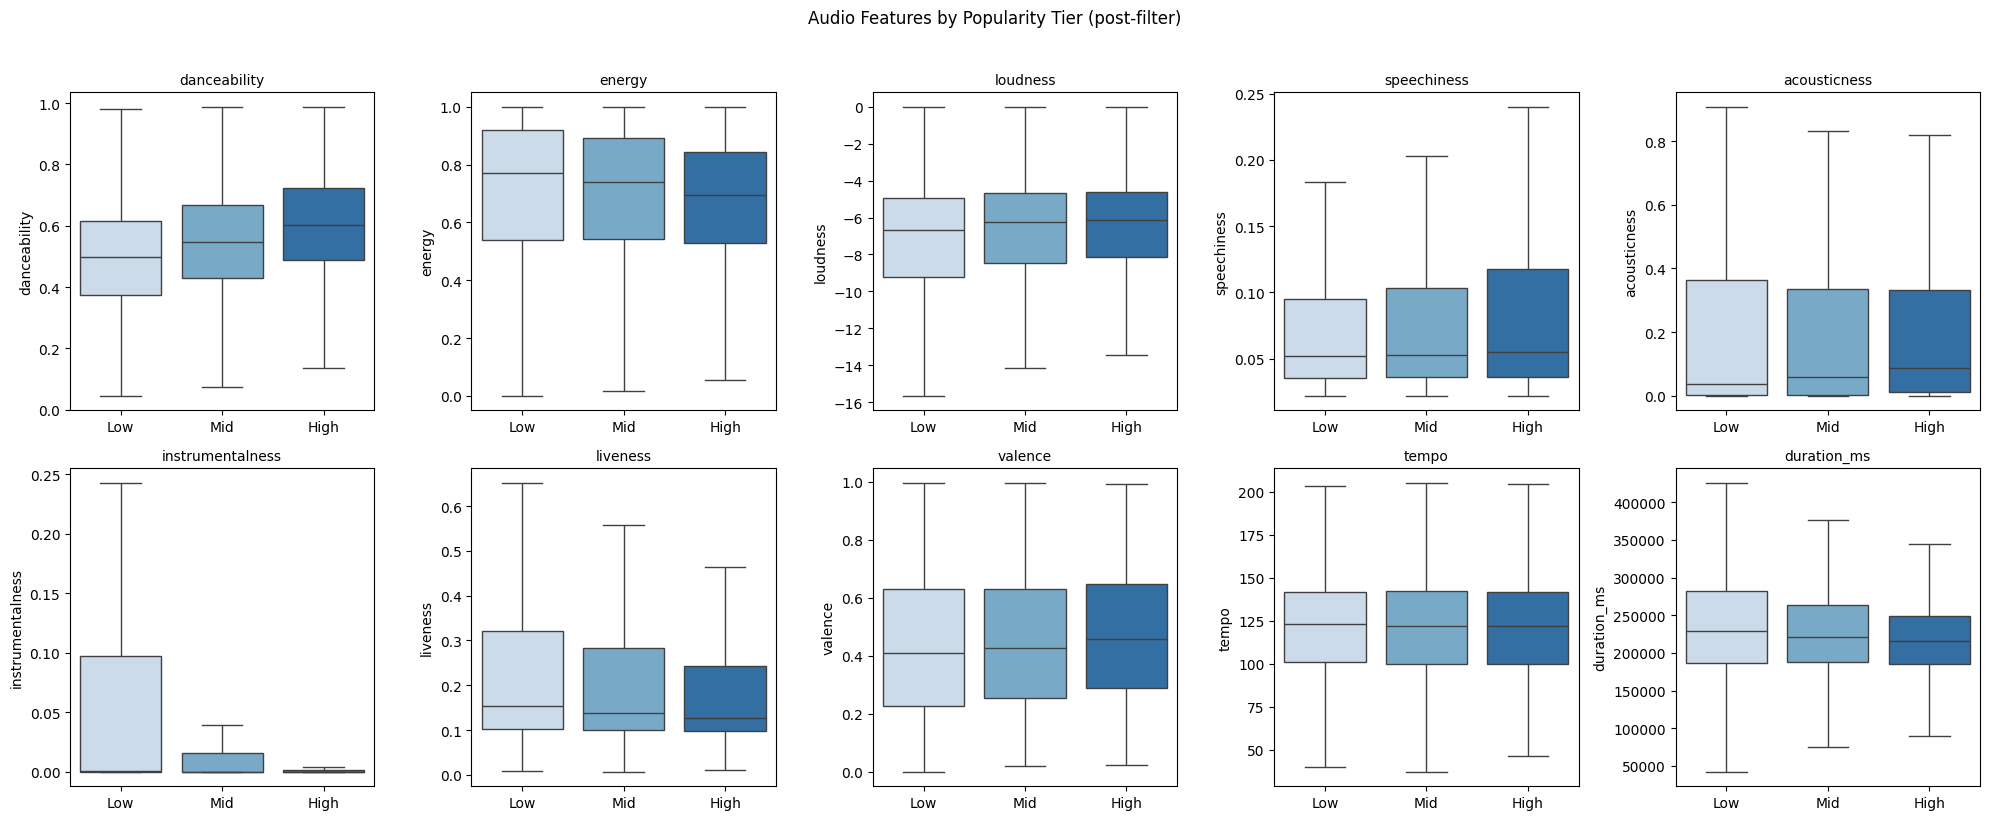

In [27]:
# post-filter feat-by-tier boxplot
temp = df_recent.copy()
temp['pop_tier'] = pd.cut(
    temp['popularity'], bins=[0, 20, 45, 100],
    labels=['Low', 'Mid', 'High'], include_lowest=True
)

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for ax, feat in zip(axes.flatten(), AUDIO_FEATURES):
    sns.boxplot(data=temp, x='pop_tier', y=feat, ax=ax,
                palette='Blues', order=['Low', 'Mid', 'High'], showfliers=False)
    ax.set_title(feat, fontsize=10)
    ax.set_xlabel('')

plt.suptitle('Audio Features by Popularity Tier (post-filter)', y=1.02)
plt.tight_layout()
plt.show()

### 4.6 Genre-Stratified Feature-Popularity Correlations

In [ ]:
# post-filter feat-pop corr by top 5 genres
top_5_genres = df_recent['genre'].value_counts().head(5).index

genre_corrs = {}
for genre in top_5_genres:
    subset = df_recent[df_recent['genre'] == genre]
    genre_corrs[genre] = subset[AUDIO_FEATURES + ['popularity']].corr()['popularity'].drop('popularity')

genre_corr_df = pd.DataFrame(genre_corrs)
genre_corr_df.plot(kind='bar', figsize=(14, 5), colormap='tab10')
plt.title('Feature-Popularity Correlation by Genre (post-filter)')
plt.ylabel('Correlation with Popularity')
plt.axhline(0, color='black', linewidth=0.8)
plt.legend(title='Genre', bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'nb00_genre_stratified_corr.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Prepare & Export Shared Datasets

Build two sampled CSVs from `df_recent` (already filtered in Section 4) and save them to Google Drive.

In [29]:
# Dataset A: genre-balanced - undersample all 7 genres to min count (Classical floor = 6,895)
GENRE_SAMPLE_N = df_recent['genre'].value_counts().min()
print(f'Sampling {GENRE_SAMPLE_N:,} songs per genre (= min-genre count)')
print(f'Total balanced dataset: {GENRE_SAMPLE_N * df_recent["genre"].nunique():,} songs')

df_genre_balanced = (
    df_recent
    .groupby('genre', group_keys=False)
    .apply(lambda x: x.sample(GENRE_SAMPLE_N, random_state=SEED))
    .reset_index(drop=True)
)

print('\nGenre-balanced dataset shape:', df_genre_balanced.shape)
print(df_genre_balanced['genre'].value_counts())

out_path = os.path.join(DRIVE_DATA_PATH, 'df_genre_balanced.csv')
df_genre_balanced[ALL_FEATURES + ['genre', 'year']].to_csv(out_path, index=False)
print(f'\nSaved: {out_path}')

Sampling 6,895 songs per genre (= min-genre count)
Total balanced dataset: 48,265 songs

Genre-balanced dataset shape: (48265, 24)
genre
Classical       6895
Country/Folk    6895
Electronic      6895
Hip-Hop/R&B     6895
Jazz/Blues      6895
Pop             6895
Rock            6895
Name: count, dtype: int64

Saved: /content/drive/MyDrive/data-mining-spotify-team3/cleanedData/df_genre_balanced.csv


In [30]:
# Dataset B: 2 popularity label targets
# 1. global class: Low/Mid/High by fixed thresholds (0-20, 21-45, 46+)
def bin_global(score, low_max=20, high_min=46):
    if score <= low_max:
        return 'Low'
    elif score >= high_min:
        return 'High'
    return 'Mid'

df_recent['popularity_class'] = df_recent['popularity'].apply(bin_global)
print('Global popularity class distribution:')
print(df_recent['popularity_class'].value_counts())

# 2. genre-relative class: within-genre percentile rank (bottom 33%=Low, top 33%=High)
df_recent['genre_pop_rank'] = df_recent.groupby('genre')['popularity'].rank(pct=True)
df_recent['genre_popularity_class'] = df_recent['genre_pop_rank'].apply(
    lambda r: 'Low' if r <= 0.33 else ('High' if r >= 0.67 else 'Mid')
)
print('\nGenre-relative popularity class distribution:')
print(df_recent['genre_popularity_class'].value_counts())

Global popularity class distribution:
popularity_class
Low     156327
Mid     134336
High     32137
Name: count, dtype: int64

Genre-relative popularity class distribution:
genre_popularity_class
Mid     110869
Low     106667
High    105264
Name: count, dtype: int64


In [31]:
# stratified sample: 500 per (popularity_class x genre) -> 10,500 rows saved to Drive
SAMPLE_PER_GROUP = 500

df_popularity_stratified = (
    df_recent
    .groupby(['popularity_class', 'genre'], group_keys=False)
    .apply(lambda x: x.sample(min(len(x), SAMPLE_PER_GROUP), random_state=SEED))
    .reset_index(drop=True)
)

print('Popularity-stratified dataset shape:', df_popularity_stratified.shape)
print('\nBy popularity class:')
print(df_popularity_stratified['popularity_class'].value_counts())
print('\nBy genre:')
print(df_popularity_stratified['genre'].value_counts())

export_cols = ALL_FEATURES + ['genre', 'year', 'popularity', 'popularity_class', 'genre_popularity_class']
out_path = os.path.join(DRIVE_DATA_PATH, 'df_popularity_stratified.csv')
df_popularity_stratified[export_cols].to_csv(out_path, index=False)
print(f'\nSaved: {out_path}')

Popularity-stratified dataset shape: (10500, 27)

By popularity class:
popularity_class
High    3500
Low     3500
Mid     3500
Name: count, dtype: int64

By genre:
genre
Classical       1500
Country/Folk    1500
Electronic      1500
Hip-Hop/R&B     1500
Jazz/Blues      1500
Pop             1500
Rock            1500
Name: count, dtype: int64

Saved: /content/drive/MyDrive/data-mining-spotify-team3/cleanedData/df_popularity_stratified.csv


---
Both datasets saved to `My Drive/data-mining-spotify-team3/cleanedData/`. Next:
- `01_genre_classification.ipynb`
- `02_popularity_prediction.ipynb`
- `03_recommendation_system.ipynb` (loads Nb 01 + Nb 02 pickles)